(annotation)=

# Annotate cell types and states

Clustering groups cells with similar expression profiles. Annotation asks what those groups
might be. We will start with broad PBMC labels, check several supporting and negative markers,
and then refine the labels where the evidence allows it.

The tissue matters: a plausible blood-cell identity may make little sense in another sample.
Use the marker patterns together with that context, and keep uncertain labels provisional.
The [](scrna_seq.ipynb) tutorial introduces the broad populations used here.

## Open the prepared analysis

In [1]:
# Import tools for marker-based cell annotation and plotting.
import numpy as np
import pandas as pd

import cytearc

# Keep routine execution diagnostics out of the marker figures.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-09T00:12:10.170775Z | Wall time: 9.000 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr")

# Open the saved analysis and retain its exact results.
run = ds.pipeline.open(label="docs_default")

# Keep the exact clustering result.
clusters = run["clusters"]

# Rank markers for the saved clusters over every gene that the run analyzed.
markers = ds.markers.search(clusters, features=run["feature_universe"])

# Read the cluster labels in the run's cell order.
cluster_values = run.cells.fetch("clusters").astype(str)

# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-09T00:12:19.173100Z | Wall time: 19.077 s

This is the same prepared result as the RNA tutorial. Cluster numbers and labels below belong
to this result; a new analysis may produce different clusters. The marker table compares each
saved cluster with the other analyzed cells, as the run's own `run["markers"]` does.

## Read the marker evidence

Start with the default marker filters and inspect one cluster:

In [3]:
# Load the marker evidence for cluster 1.
group_markers = ds.markers.load(marker=markers, group_id="1")

# Inspect the ten leading markers and their supporting statistics.
marker_columns = [
    "feature_name",
    "score",
    "frac_exp",
    "fold_change",
    "auc",
    "p_value_adjusted",
]

# Preview the ten leading rows using those evidence columns.
group_markers[marker_columns].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value_adjusted
0,S100A12,0.95602,0.93994,815.52981,0.96916,0.0
1,VCAN,0.92671,0.96648,360.28912,0.98244,0.0
2,CD14,0.92058,0.95251,419.17110,0.97550,0.0
3,ALDH1A1,0.90655,0.51816,646.32933,0.75854,0.0
4,CLEC4E,0.90604,0.58659,834.76424,0.79282,0.0
5,LGALS2,0.90343,0.55587,243.49814,0.77642,0.0
6,CD163,0.89437,0.50419,433.35070,0.75137,0.0
7,QPCT,0.88468,0.46788,370.17063,0.73317,0.0
8,CYP27A1,0.88372,0.46648,363.40352,0.73234,0.0
9,STAB1,0.87741,0.62430,93.18504,0.80792,0.0


Started: 2026-10-09T00:12:38.253024Z | Wall time: 0.119 s

Each row compares expression in this cluster with the rest of the analyzed cells.

| Column | How to read it |
| --- | --- |
| `frac_exp` | Fraction of cells with detected expression, from 0 to 1. A value of 0.8 means 80% of the cluster. |
| `fold_change` | Mean expression in the cluster divided by the mean in the other cells. It is `inf` for a gene that no other cell expresses and `NaN` for a gene that no cell expresses. Check detection too: a few cells can drive a large difference. |
| `auc` | Values above 0.5 favour higher expression in this cluster; below 0.5 favour the other cells. A value near 0.5 gives little separation. |
| `score` | A relative specificity score based on expression ranks across clusters. It is not a detection fraction or a probability of cell identity. |
| `p_value_adjusted` | A two-sided Mann-Whitney p-value with Benjamini-Hochberg correction within the cluster's tested genes. It does not account for biological replication. |

A low specificity score does not establish that a gene is absent. Read `frac_exp` for detection
and compare it with `frac_exp_rest` when evaluating negative evidence.

`fold_change` is a ratio of the means of the values that the marker search ranks: here,
library-size normalized counts. Sorted from high to low, genes that only this cluster expresses
come first with `inf`, however faint, and genes that no cell expresses come last with `NaN`. With
`log_transform=True`, or for an ADT assay normalized with CLR, the ranked values are on a log
scale, so the ratio compares log-scale means and is not a fold change in expression. Compare fold
changes only between results of the same assay and normalization.

## Assign initial cell types

Plot a few familiar markers alongside the clusters. Drawing high values last makes sparse
expression easier to see in these panels.

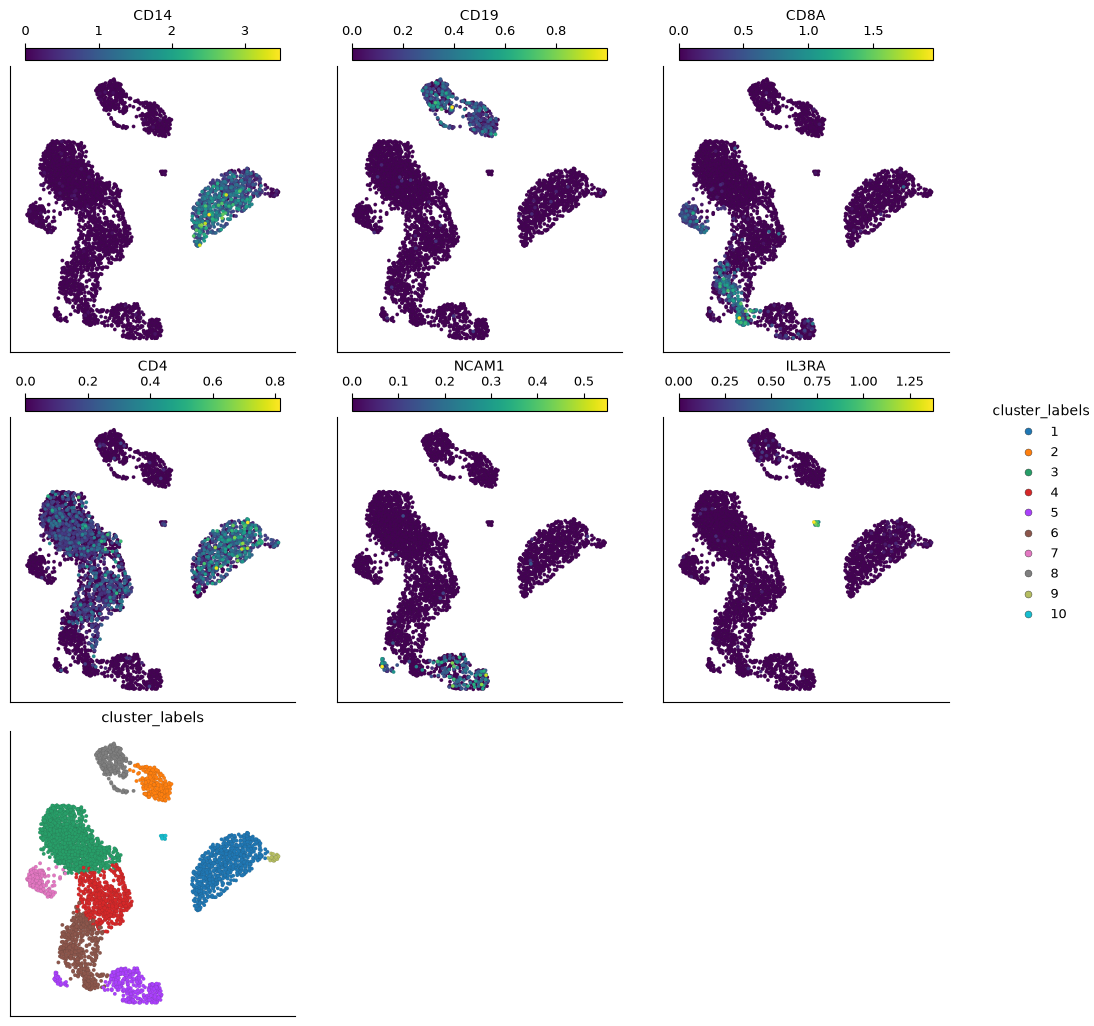

Started: 2026-10-09T00:12:38.374331Z | Wall time: 4.420 s

In [4]:
# Choose a small marker panel for the comparison.
panel_genes = ["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA"]

# Compare the initial marker panel with the saved clusters.
ds.plots.embedding(
    layout=run["umap"], color_by=[*panel_genes, clusters], n_columns=3, sort_values=True
)

CD14 suggests a monocyte population, CD19 highlights candidate B cells, and NCAM1 (CD56)
highlights an NK-like population. CD8A and CD4 help locate candidate T-cell groups, but neither
is sufficient alone. In this example, CD4's highest specificity score is in monocyte cluster 1.
CD19 points to cluster 8, CD8A to cluster 7, and NCAM1 to cluster 5. These associations help
locate candidate populations; they do not make any of these genes a unique lineage marker.
IL3RA suggests a pDC-like population that we will check with other markers.

The default marker filters hide weak and negative evidence. For the remaining comparisons,
load all marker rows once by relaxing both filters. Keep this table for the later panels.

In [5]:
# Include weak and negative marker evidence for the remaining checks.
all_markers = ds.markers.load(marker=markers, min_score=-1, min_frac_exp=-1)

# Keep the marker statistics for the chosen genes.
panel_stats = all_markers[all_markers["feature_name"].isin(panel_genes)]

# Find the highest-scoring cluster for each marker.
panel_best = (
    panel_stats.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")
    .reindex(panel_genes)
)

# Inspect the strongest cluster association for each panel gene.
panel_best[["group_id", "score", "frac_exp", "auc"]].round(2)

,group_id,score,frac_exp,auc
feature_name,,,,
CD14,1,0.92,0.95,0.98
CD19,8,0.54,0.61,0.78
CD8A,7,0.49,0.88,0.89
CD4,1,0.34,0.75,0.77
NCAM1,5,0.76,0.40,0.70
IL3RA,10,0.81,1.00,1.00


Started: 2026-10-09T00:12:42.798389Z | Wall time: 0.564 s

These are starting hypotheses. Several clusters receive the same broad name:

In [6]:
# Record broad identities to check against the full marker evidence.
proposed_labels = {
    "1": "CD14 monocytes",
    "2": "B cells",
    "3": "T cells",
    "4": "T cells",
    "5": "NK cells",
    "6": "T cells",
    "7": "T cells",
    "8": "B cells",
    "9": "monocytes",
    "10": "pDC-like cells",
}

# Display the initial cluster-to-cell-type proposals.
pd.Series(proposed_labels, name="proposed_cell_type")

1     CD14 monocytes
2            B cells
3            T cells
4            T cells
5           NK cells
6            T cells
7            T cells
8            B cells
9          monocytes
10    pDC-like cells
Name: proposed_cell_type, dtype: str

Started: 2026-10-09T00:12:43.364140Z | Wall time: 0.007 s

## Look for several supporting markers

A heatmap helps us check whether several genes support each proposed identity. Show the three
leading markers per cluster, with enough width to read the cluster labels:

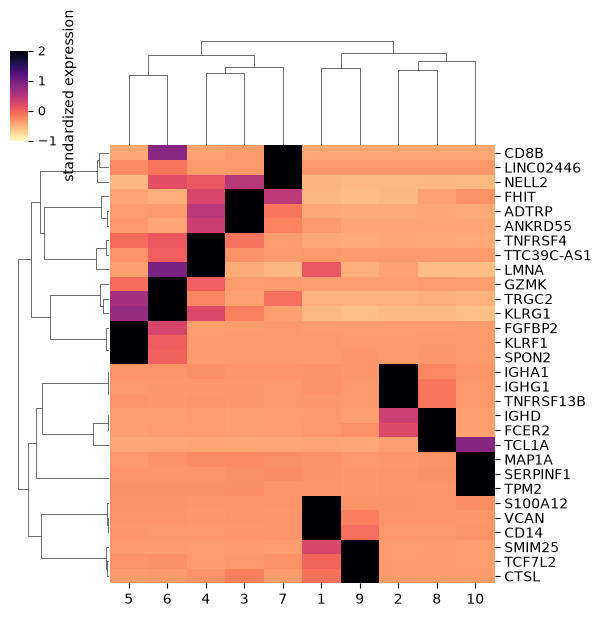

Started: 2026-10-09T00:12:43.372829Z | Wall time: 1.912 s

In [7]:
# Compare the leading markers across the saved clusters.
ds.plots.marker_heatmap(marker=markers, topn=3, figsize=(6, 6))

Read each column's cluster number before interpreting the heatmap. The column order follows
marker similarity, so it is not numerical order.

- **Monocytes:** cluster 1 has S100A12, VCAN, and CD14. Cluster 9 has a distinct CTSL, TCF7L2,
  and SMIM25 pattern. Keep its broader monocyte label while investigating its state.
- **B cells:** IGHD, FCER2, and TCL1A support a naive B-cell interpretation for cluster 8.
  IGHA1, TNFRSF13B, and IGHG1 support a memory-like B-cell population in cluster 2.
- **NK and T cells:** KLRF1, FGFBP2, and SPON2 support an NK interpretation for cluster 5.
  Cluster 6 has a GZMK, TRGC2, and KLRG1 pattern; inspect T-cell markers before interpreting
  its cytotoxic program. Cluster 7 has CD8B among its leading markers.
- **Other T-cell groups:** clusters 3 and 4 retain broad T-cell labels. Their different leading
  markers are a reason to inspect their states, not sufficient evidence to name a subtype.
- **pDC-like cells:** SERPINF1 in cluster 10 supports the initial IL3RA association, but the
  short heatmap panel does not settle this rare population's identity. Keep the label provisional.

For finer T-cell labels, compare clusters 6 and 7 using a small panel:


In [8]:
# Choose markers for T-cell identity and state.
t_cell_genes = ["CD3D", "CD8A", "CD8B", "CCR7", "IL7R", "CD27", "GZMK"]

# Select the marker rows for the cytotoxic and candidate naive T-cell groups.
t_cell_evidence = all_markers[
    all_markers["group_id"].isin(["6", "7"])
    & all_markers["feature_name"].isin(t_cell_genes)
]

# Inspect T-cell marker detection and specificity in clusters 6 and 7.
t_cell_evidence[["group_id", "feature_name", "frac_exp", "score"]].round(2)

,group_id,feature_name,frac_exp,score
167690,6,GZMK,0.71,0.78
167697,6,CD8A,0.48,0.41
167748,6,CD8B,0.46,0.28
167779,6,CD3D,0.98,0.26
167840,6,IL7R,0.72,0.23
169234,6,CD27,0.52,0.14
200793,6,CCR7,0.12,0.02
201229,7,CD8B,0.95,0.68
201233,7,CD8A,0.88,0.49
201255,7,CCR7,0.85,0.30


Started: 2026-10-09T00:12:45.286998Z | Wall time: 0.048 s

Cluster 6 has a GZMK-associated cytotoxic T-cell pattern. Cluster 7 combines frequent CD8A and
CD8B detection with CCR7, IL7R, and CD27, supporting a naive-like CD8 interpretation. GZMK is
rarely detected in cluster 7. These descriptions remain hypotheses about state, not proof of a
separate lineage.

## Check competing identities

Cytotoxic genes are shared by NK cells and some T cells. Compare the candidate NK cluster 5
with T-cell clusters 6 and 7 using CD3D and CD3E, then inspect CD4, CD8A, and CD8B:


In [9]:
# Choose markers that distinguish the competing cell identities.
comparison_genes = ["CD3D", "CD3E", "CD4", "NKG7", "GNLY", "CD8A", "CD8B"]

# Keep evidence for the NK and T-cell populations under review.
comparison = all_markers[
    all_markers["group_id"].isin(["5", "6", "7"])
    & all_markers["feature_name"].isin(comparison_genes)
]

# Compare marker detection inside and outside the competing populations.
comparison[["group_id", "feature_name", "frac_exp", "frac_exp_rest", "auc"]].round(2)

,group_id,feature_name,frac_exp,frac_exp_rest,auc
134163,5,GNLY,1.00,0.11,1.00
134199,5,NKG7,1.00,0.21,0.99
141994,5,CD3D,0.31,0.65,0.40
143129,5,CD3E,0.42,0.66,0.40
166592,5,CD8A,0.11,0.11,0.50
167586,5,CD4,0.02,0.39,0.31
167633,5,CD8B,0.00,0.12,0.44
167697,6,CD8A,0.48,0.06,0.72
167723,6,NKG7,0.89,0.18,0.86
167748,6,CD8B,0.46,0.06,0.70


Started: 2026-10-09T00:12:45.336620Z | Wall time: 0.048 s

In cluster 6, CD3D and CD3E are detected in almost all cells, alongside NKG7 in most cells.
This supports a T-cell interpretation despite the cytotoxic program. Calling this cluster NK
from NKG7 alone would miss the T-cell evidence. For candidate NK cluster 5, check whether the
T-cell markers are depleted relative to the cytotoxic markers.

In cluster 7, frequent CD8A and CD8B detection supports the CD8 T-cell label. Check CD4 and other
competing lineages in the same way; low detection of one marker does not establish that a
population is pure. Cluster-level averages can also hide mixtures within a group.

## Save and compare the reviewed labels

Keep the broad labels where we have not established a finer identity. Update the groups with
additional supporting evidence:


In [10]:
# Refine only the identities supported by the additional evidence.
final_labels = proposed_labels | {
    "2": "memory-like B cells",
    "7": "naive-like CD8 T cells",
    "8": "naive B cells",
}

# Put the initial and reviewed labels beside each other.
label_review = pd.DataFrame({"initial": proposed_labels, "reviewed": final_labels})

# Display only the labels changed during review.
label_review.loc[label_review["initial"] != label_review["reviewed"]]

,initial,reviewed
2,B cells,memory-like B cells
7,T cells,naive-like CD8 T cells
8,B cells,naive B cells


Started: 2026-10-09T00:12:45.387163Z | Wall time: 0.009 s

The cell table includes cells outside this run. Align the labels to the run's selection before
saving them. Rerunning this cell replaces the two annotation columns, leaving the computed
clusters unchanged.

In [11]:
# Locate the run's selected cells on the full metadata axis.
analysis_cells = run.cells.fetch_all("I").astype(bool)

# Reserve a label for every cell, including cells outside the run.
initial_cell_type = np.full(ds.cells.N, "Not analyzed", dtype=object)

# Reserve the same full cell axis for the reviewed labels.
reviewed_cell_type = np.full(ds.cells.N, "Not analyzed", dtype=object)

# Place the initial labels into the selected physical rows.
initial_cell_type[analysis_cells] = [proposed_labels[value] for value in cluster_values]

# Place the reviewed labels into those same rows.
reviewed_cell_type[analysis_cells] = [final_labels[value] for value in cluster_values]

# Save the values in cell metadata using the stated selection.
ds.cells.insert("proposed_cell_type", initial_cell_type, overwrite=True)

# Save the values in cell metadata using the stated selection.
ds.cells.insert("reviewed_cell_type", reviewed_cell_type, overwrite=True)

# Count cells assigned to each reviewed identity.
pd.Series(reviewed_cell_type[analysis_cells]).value_counts().rename("cells")

T cells                   2230
CD14 monocytes             716
NK cells                   318
naive B cells              256
memory-like B cells        239
naive-like CD8 T cells     149
monocytes                   25
pDC-like cells              15
Name: cells, dtype: int64

Started: 2026-10-09T00:12:45.397487Z | Wall time: 0.066 s

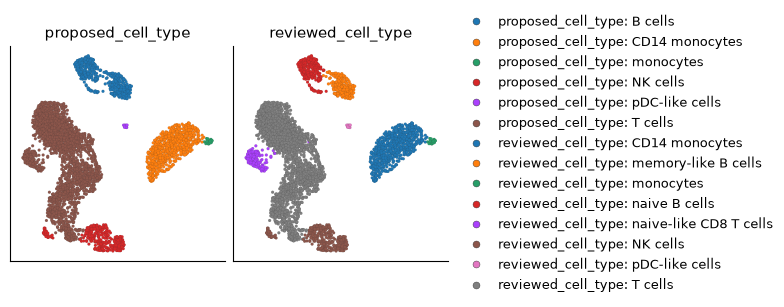

Started: 2026-10-09T00:12:45.465621Z | Wall time: 1.281 s

In [12]:
# Compare the original and reviewed annotations on the same UMAP.
ds.plots.embedding(
    layout=run["umap"], color_by=["proposed_cell_type", "reviewed_cell_type"]
)

The saved `naive-like CD8 T cells` and `memory-like B cells` labels summarize the interpretations above.
They are provisional teaching labels for this dataset. Keep the marker evidence and the run
identity with them when recording an analysis.

## What still needs review?

Clusters can separate continuous states within one lineage. Compare marker evidence across
partitions with [](clustering.ipynb) before treating each cluster as a distinct cell type.

Mixed lineage markers may reflect doublets, background RNA, or uncertain identity. Check
per-cell evidence and [](quality_control.ipynb); a cluster-average score cannot settle the question.
Rare populations deserve this review as much as large ones.

These marker statistics compare cells. Use [](pseudobulk_and_differential_expression.ipynb) for
questions about differences between biological conditions. Use [](mapping_and_label_transfer.ipynb)
when transferring labels from a fixed reference.

## Find marker references for your tissue

Use resources as evidence to compare with your measured markers, rather than a list of names
to assign automatically:

- Marker collections: [CellMarker](http://bio-bigdata.hrbmu.edu.cn/CellMarker/),
  [PanglaoDB](https://panglaodb.se/), and [Human Protein Atlas](https://www.proteinatlas.org/).
- Reference atlases and annotation tools: [Azimuth](https://azimuth.hubmapconsortium.org/),
  [ScType](https://github.com/IanevskiAleksandr/sc-type), [CellTypist](https://www.celltypist.org/),
  [SingleR](https://bioconductor.org/packages/release/bioc/html/SingleR.html), and
  [CyteType](https://www.nygen.io/products/cytetype).
- Gene-list interpretation: [Enrichr](https://maayanlab.cloud/Enrichr/) and
  [ToppGene](https://toppgene.cchmc.org/).
- Protein-marker panels: [BioLegend](https://www.biolegend.com/en-us/cell-markers),
  [BD Biosciences](https://www.bdbiosciences.com/), and
  [OMIPs in Cytometry Part A](https://onlinelibrary.wiley.com/journal/15524930).